# PyTorch Binary Classification — Breast Cancer Dataset

## Learning goals

By the end, you will be able to:

1. explain binary classification, logits, sigmoid, and probability thresholds;
2. build an MLP with one raw output logit;
3. use `BCEWithLogitsLoss` correctly;
4. understand `pos_weight` and its trade-off;
5. use a cosine learning-rate scheduler;
6. report confusion matrix, precision, recall, and F1;
7. choose a threshold using validation data.

## Dataset story

The Wisconsin Breast Cancer dataset contains **569 samples**, **30 numeric features**, and two labels.

For this notebook we deliberately define:

```text
0 = benign
1 = malignant  ← positive class requiring attention
```

## 1. What is binary classification?

Binary classification chooses between two classes.

```text
30 patient measurements → neural network → 1 raw logit
                                             │
                                             ▼
                                          sigmoid
                                             │
                                             ▼
                                      probability 0 to 1
                                             │
                                      compare with threshold
                                             │
                                      benign or malignant
```

In [1]:
# WHAT: Import libraries and fix random seeds.
# WHY: Reproducibility makes the classroom output stable.
# OUTPUT: PyTorch version and CPU device.

import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print("torch:", torch.__version__, "| device:", device)

torch: 2.12.0 | device: cpu


## 2. Load the data and define the positive class

The original scikit-learn target uses `0 = malignant` and `1 = benign`. We reverse it so that the class needing attention becomes positive:

```python
y = 1 - original_target
```

This mapping must be written down and kept consistent during training, metrics, and deployment.

In [2]:
# WHAT: Load the dataset and remap malignant to label 1.
# WHY: Precision and recall are calculated for the positive class, so the mapping matters.
# OUTPUT: 569 rows, 30 features, and counts for benign/malignant labels.

data = load_breast_cancer()
X_all = data.data.astype("float32")
y_all = (1 - data.target).astype("int64")  # 0=benign, 1=malignant

print("X shape:", X_all.shape)
print("y shape:", y_all.shape)
print("first five feature names:", data.feature_names[:5].tolist())
print("benign count   (0):", int((y_all == 0).sum()))
print("malignant count(1):", int((y_all == 1).sum()))

X shape: (569, 30)
y shape: (569,)
first five feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
benign count   (0): 357
malignant count(1): 212


## 3. Stratified train, validation, and test split

`stratify=y` keeps a similar benign/malignant ratio in every subset.

```text
TRAIN       learns weights
VALIDATION  chooses checkpoint and threshold
TEST        final evaluation
```

In [3]:
# WHAT: Make stratified train, validation, and test splits.
# WHY: Each small subset should keep a similar class ratio.
# OUTPUT: Split sizes and malignant rates.

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.40,
    stratify=y_all,
    random_state=SEED,
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED,
)

for name, X_part, y_part in [
    ("train", X_train, y_train),
    ("valid", X_valid, y_valid),
    ("test", X_test, y_test),
]:
    print(f"{name:<5}: rows={len(X_part):>3} | malignant rate={y_part.mean():.3f}")

train: rows=341 | malignant rate=0.372
valid: rows=114 | malignant rate=0.377
test : rows=114 | malignant rate=0.368


## 4. Scale features using training data only

Some measurements are small decimals and others are much larger. Standardization helps the optimizer work with them together.

Targets are **not** standardized. Binary targets remain `0.0` and `1.0` floats for `BCEWithLogitsLoss`.

In [4]:
# WHAT: Scale input features and create float32 tensors.
# WHY: Stable feature ranges help optimization; BCE targets must be float values.
# OUTPUT: Feature shape `(N, 30)` and target shape `(N, 1)`.

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype("float32")
X_valid_s = scaler.transform(X_valid).astype("float32")
X_test_s = scaler.transform(X_test).astype("float32")

def to_float_tensor(array):
    return torch.tensor(array, dtype=torch.float32, device=device)

Xtr = to_float_tensor(X_train_s)
Xva = to_float_tensor(X_valid_s)
Xte = to_float_tensor(X_test_s)

ytr = to_float_tensor(y_train).view(-1, 1)
yva = to_float_tensor(y_valid).view(-1, 1)
yte = to_float_tensor(y_test).view(-1, 1)

print("X train:", Xtr.dtype, tuple(Xtr.shape))
print("y train:", ytr.dtype, tuple(ytr.shape), "unique:", ytr.unique().tolist())

X train: torch.float32 (341, 30)
y train: torch.float32 (341, 1) unique: [0.0, 1.0]


## 5. Logit, sigmoid, probability, decision

- **Logit:** unrestricted raw model score such as `-2.0`, `0.4`, or `3.1`.
- **Sigmoid:** converts a logit into a value between `0` and `1`.
- **Threshold:** converts probability into a final class.

```text
logit -2.0 → sigmoid ≈ 0.119 → below 0.5 → predict benign
logit  0.0 → sigmoid = 0.500 → at threshold
logit  2.0 → sigmoid ≈ 0.881 → above 0.5 → predict malignant
```

During training, send raw logits directly to `BCEWithLogitsLoss`.

In [5]:
# WHAT: Convert three example logits with sigmoid and apply threshold 0.5.
# WHY: This example shows score -> probability -> decision as separate steps.
# OUTPUT: Probabilities and binary predictions.

example_logits = torch.tensor([-2.0, 0.0, 2.0])
example_probabilities = torch.sigmoid(example_logits)
example_predictions = (example_probabilities >= 0.5).int()

for logit, probability, prediction in zip(
    example_logits, example_probabilities, example_predictions
):
    print(f"logit={logit.item():>4.1f} | probability={probability.item():.3f} "
          f"| prediction={prediction.item()}")

logit=-2.0 | probability=0.119 | prediction=0
logit= 0.0 | probability=0.500 | prediction=1
logit= 2.0 | probability=0.881 | prediction=1


## 6. Build a binary-classification MLP

```text
30 input features → 32 hidden → 16 hidden → 1 raw logit
```

The final layer has exactly **one output**.

Do not put sigmoid inside the model when training with `BCEWithLogitsLoss`. PyTorch combines sigmoid and binary cross-entropy internally using a stable calculation.

In [6]:
# WHAT: Define an MLP that returns one raw logit per patient.
# WHY: BCEWithLogitsLoss expects logits, not already-sigmoided probabilities.
# OUTPUT: Model structure, parameter count, and output shape `(4, 1)`.

class BinaryMLP(nn.Module):
    def __init__(self, in_features=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),  # one RAW LOGIT; no sigmoid here
        )

    def forward(self, x):
        return self.net(x)

model = BinaryMLP().to(device)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

with torch.inference_mode():
    sample_logits = model(Xtr[:4])
print("output shape:", tuple(sample_logits.shape))
print("raw logits:", sample_logits.squeeze().tolist())

BinaryMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)
trainable parameters: 1537
output shape: (4, 1)
raw logits: [0.10428892076015472, 0.12103139609098434, 0.11016968637704849, 0.05231090635061264]


## 7. `BCEWithLogitsLoss` and `pos_weight`

There are fewer malignant rows than benign rows. A common starting value is:

```text
pos_weight = number of negative examples / number of positive examples
```

`pos_weight` multiplies the loss contribution of true positive-label examples. It does **not** change labels and it does **not** directly set the probability threshold.

Expected trade-off:

- recall can increase;
- precision can decrease;
- probability calibration should be checked separately.

In [7]:
# WHAT: Calculate `pos_weight` from the training split only.
# WHY: Positive malignant examples receive more importance in the training loss.
# OUTPUT: Negative count, positive count, and their ratio.

positive_count = int((y_train == 1).sum())
negative_count = int((y_train == 0).sum())
pos_weight = torch.tensor(
    [negative_count / positive_count],
    dtype=torch.float32,
    device=device,
)

print("negative/benign count   :", negative_count)
print("positive/malignant count:", positive_count)
print("pos_weight              :", round(pos_weight.item(), 3))

negative/benign count   : 214
positive/malignant count: 127
pos_weight              : 1.685


## 8. Why this notebook uses cosine scheduling

```python
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=250, eta_min=1e-5
)
```

This binary-classification lesson has a known maximum training budget of 250 epochs. Cosine scheduling gives a smooth planned reduction:

```text
larger LR early → smaller LR near the final epochs
```

It is simple to teach because the LR plan depends on the known training length, not on noisy validation changes.

### What if we use another scheduler?

| Choice | What would happen here? |
|---|---|
| `ReduceLROnPlateau` | It could work. LR would drop only after validation BCE stopped improving, but the exact drop time would depend on patience and validation noise. |
| `OneCycleLR` | It could work with mini-batches, a known `steps_per_epoch`, and a safe `max_lr`. This notebook uses one full batch per epoch, so it would not show the usual OneCycle pattern clearly. |
| No scheduler | The classifier may still learn, but one constant LR may be too large near a good solution or too small during early learning. |

In [8]:
# WHAT: Create weighted BCE, AdamW, and a cosine scheduler.
# WHY: BCE trains binary logits; cosine gives smooth decay for this fixed 250-epoch plan.
# ALTERNATIVE: Plateau reacts to validation BCE; OneCycle needs mini-batch steps and a safe max_lr.
# OUTPUT: Loss configuration and initial learning rate.

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=3e-3, weight_decay=1e-3
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=250,
    eta_min=1e-5,
)

print("initial learning rate:", optimizer.param_groups[0]["lr"])
print("positive loss weight  :", pos_weight.item())

initial learning rate: 0.003
positive loss weight  : 1.6850394010543823


## 9. Binary training loop

```text
TRAIN
logits = model(X_train)
loss = BCEWithLogitsLoss(logits, labels)
zero_grad → backward → optimizer.step → scheduler.step

VALIDATE
model.eval + inference_mode
validation loss
save best state
```

This small dataset uses full-batch training to keep the code readable. Large datasets normally use mini-batches and `DataLoader`.

In [9]:
# WHAT: Define full-batch binary training with validation and best-state restore.
# WHY: Training and validation modes must stay separate; final evaluation uses best weights.
# OUTPUT: History of train loss, validation loss, and cosine learning rate.

def train_binary(model, X_train, y_train, X_valid, y_valid,
                 optimizer, scheduler, loss_fn,
                 epochs=250, early_stop_patience=40):
    history = {"train": [], "valid": [], "lr": []}
    best_valid = float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        # ----- TRAIN -----
        model.train()
        train_logits = model(X_train)
        train_loss = loss_fn(train_logits, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        scheduler.step()  # planned once-per-epoch cosine update

        # ----- VALIDATE -----
        model.eval()
        with torch.inference_mode():
            valid_logits = model(X_valid)
            valid_loss = loss_fn(valid_logits, y_valid).item()

        history["train"].append(train_loss.item())
        history["valid"].append(valid_loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if valid_loss < best_valid - 1e-4:
            best_valid = valid_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch == 1 or epoch % 50 == 0:
            print(f"epoch {epoch:>3} | train BCE {train_loss.item():.4f} "
                  f"| valid BCE {valid_loss:.4f} "
                  f"| lr {optimizer.param_groups[0]['lr']:.6f}")

        if bad_epochs >= early_stop_patience:
            print("early stopping at epoch", epoch)
            break

    model.load_state_dict(best_state)
    print(f"restored epoch {best_epoch} with validation BCE {best_valid:.4f}")
    return history

In [10]:
# WHAT: Train the binary classifier.
# WHY: This performs learning, cosine decay, validation, and checkpoint restore.
# OUTPUT: Training progress and a populated history.

history = train_binary(
    model, Xtr, ytr, Xva, yva,
    optimizer, scheduler, loss_fn,
)

epoch   1 | train BCE 0.8900 | valid BCE 0.8737 | lr 0.003000
epoch  50 | train BCE 0.1045 | valid BCE 0.0691 | lr 0.002714
epoch 100 | train BCE 0.0659 | valid BCE 0.0600 | lr 0.001967
early stopping at epoch 127
restored epoch 87 with validation BCE 0.0572


## 10. Read the training curves

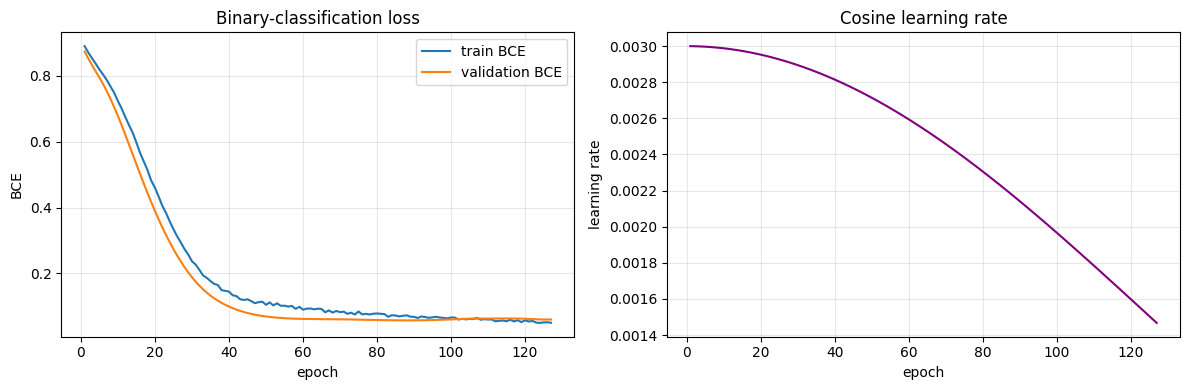

In [11]:
# WHAT: Plot BCE losses and the cosine learning rate.
# WHY: Curves show learning progress, generalization, and scheduler behaviour.
# OUTPUT: Loss and learning-rate plots.

epochs_run = range(1, len(history["train"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_run, history["train"], label="train BCE")
axes[0].plot(epochs_run, history["valid"], label="validation BCE")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE")
axes[0].set_title("Binary-classification loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_run, history["lr"], color="purple")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("learning rate")
axes[1].set_title("Cosine learning rate")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Convert logits into probabilities

Now—and only now—we apply sigmoid.

```text
logit → sigmoid → probability → threshold → class
```

We first use threshold `0.50`, then choose another threshold using validation cost.

In [12]:
# WHAT: Produce validation and test probabilities from the restored model.
# WHY: Metrics and threshold decisions need probabilities, while training needed logits.
# OUTPUT: Probability ranges between 0 and 1.

model.eval()
with torch.inference_mode():
    valid_probability = torch.sigmoid(model(Xva)).squeeze(1).cpu().numpy()
    test_probability = torch.sigmoid(model(Xte)).squeeze(1).cpu().numpy()

print("validation probability min/max:",
      round(valid_probability.min(), 4), round(valid_probability.max(), 4))
print("test probability min/max      :",
      round(test_probability.min(), 4), round(test_probability.max(), 4))

validation probability min/max: 0.0 1.0
test probability min/max      : 0.0 1.0


## 12. Metrics at threshold 0.50

For positive class `1 = malignant`:

- **Precision:** out of predicted malignant cases, how many were actually malignant?
- **Recall:** out of actual malignant cases, how many did we find?
- **F1:** balance between precision and recall.
- **False negative:** malignant case predicted benign—important here.

Accuracy alone is not enough.

In [13]:
# WHAT: Evaluate the test set using the default threshold 0.50.
# WHY: We need class-wise metrics and a confusion matrix, not only accuracy.
# OUTPUT: Accuracy, precision, recall, F1, and classification report.

default_threshold = 0.50
test_prediction_05 = (test_probability >= default_threshold).astype("int64")

print("accuracy :", round(accuracy_score(y_test, test_prediction_05), 3))
print("precision:", round(precision_score(y_test, test_prediction_05), 3))
print("recall   :", round(recall_score(y_test, test_prediction_05), 3))
print("F1       :", round(f1_score(y_test, test_prediction_05), 3))

print("\n", classification_report(
    y_test,
    test_prediction_05,
    target_names=["benign", "malignant"],
    digits=3,
))

accuracy : 0.974
precision: 1.0
recall   : 0.929
F1       : 0.963

               precision    recall  f1-score   support

      benign      0.960     1.000     0.980        72
   malignant      1.000     0.929     0.963        42

    accuracy                          0.974       114
   macro avg      0.980     0.964     0.971       114
weighted avg      0.975     0.974     0.973       114



rows=actual, columns=predicted
[[72  0]
 [ 3 39]]


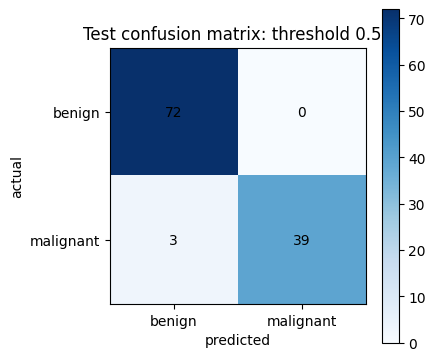

In [14]:
# WHAT: Draw the confusion matrix at threshold 0.50.
# WHY: The matrix shows false positives and false negatives directly.
# OUTPUT: A labeled 2x2 matrix.

cm_05 = confusion_matrix(y_test, test_prediction_05, labels=[0, 1])
print("rows=actual, columns=predicted")
print(cm_05)

fig, ax = plt.subplots(figsize=(4.5, 4))
image = ax.imshow(cm_05, cmap="Blues")
ax.set_xticks([0, 1], ["benign", "malignant"])
ax.set_yticks([0, 1], ["benign", "malignant"])
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("Test confusion matrix: threshold 0.50")

for row in range(2):
    for column in range(2):
        ax.text(column, row, cm_05[row, column], ha="center", va="center")

plt.colorbar(image)
plt.tight_layout()
plt.show()

## 13. Choose a threshold on validation data

Assume this classroom cost:

```text
one false negative costs 5 points
one false positive costs 1 point
total cost = 5 × FN + 1 × FP
```

This makes missing a malignant case more expensive than sending a benign case for an extra check.

The real cost must come from domain experts. We use a simple example only to teach the method.

In [15]:
# WHAT: Sweep thresholds using validation data and minimize a simple business cost.
# WHY: The threshold should reflect false-negative/false-positive trade-offs.
# OUTPUT: Best validation threshold and its validation confusion values.

thresholds = np.arange(0.10, 0.91, 0.05)
rows = []

for threshold in thresholds:
    prediction = (valid_probability >= threshold).astype("int64")
    tn, fp, fn, tp = confusion_matrix(
        y_valid, prediction, labels=[0, 1]
    ).ravel()
    cost = 5 * fn + 1 * fp
    rows.append((threshold, cost, tn, fp, fn, tp))

best_threshold, best_cost, tn, fp, fn, tp = min(rows, key=lambda row: row[1])

print("best validation threshold:", round(float(best_threshold), 2))
print("validation cost:", int(best_cost))
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

best validation threshold: 0.2
validation cost: 0
TN=71, FP=0, FN=0, TP=43


In [16]:
# WHAT: Apply the chosen validation threshold to the untouched test probabilities.
# WHY: Threshold selection and final evaluation must use different subsets.
# OUTPUT: Final test confusion matrix, precision, recall, and F1.

final_test_prediction = (test_probability >= best_threshold).astype("int64")
final_cm = confusion_matrix(y_test, final_test_prediction, labels=[0, 1])

print("chosen threshold:", round(float(best_threshold), 2))
print("test confusion matrix:\n", final_cm)
print("precision:", round(precision_score(y_test, final_test_prediction), 3))
print("recall   :", round(recall_score(y_test, final_test_prediction), 3))
print("F1       :", round(f1_score(y_test, final_test_prediction), 3))

chosen threshold: 0.2
test confusion matrix:
 [[69  3]
 [ 1 41]]
precision: 0.932
recall   : 0.976
F1       : 0.953


In [17]:
# WHAT: Print a few individual probabilities and decisions.
# WHY: Concrete rows make the threshold idea easier to explain.
# OUTPUT: Actual label, malignant probability, and final predicted label.

print(f"{'actual':>8} {'p(malignant)':>14} {'predicted':>10}")
for actual, probability, prediction in zip(
    y_test[:8], test_probability[:8], final_test_prediction[:8]
):
    print(f"{actual:8d} {probability:14.3f} {prediction:10d}")

  actual   p(malignant)  predicted
       0          0.011          0
       0          0.016          0
       0          0.006          0
       0          0.000          0
       0          0.006          0
       0          0.037          0
       0          0.005          0
       0          0.087          0


## 14. Common mistakes

| Mistake | Why it is wrong |
|---|---|
| add sigmoid inside model, then use `BCEWithLogitsLoss` | sigmoid is applied twice |
| target dtype is `int64` | BCE targets should be float `0.0/1.0` |
| model output `(N,)`, target `(N,1)` | shape mismatch or unwanted broadcasting |
| call softmax for binary one-logit output | use sigmoid for one binary logit |
| choose threshold on test | test information leaks into decisions |
| say `pos_weight` changes threshold | it changes the training loss, not the threshold directly |
| report only accuracy | it can hide false negatives |

> **Remember:** raw logits go into `BCEWithLogitsLoss`; sigmoid is for probability interpretation afterward.

## 15. Practice

Try these one at a time:

1. Train without `pos_weight` and compare malignant recall.
2. Compare thresholds `0.30`, `0.50`, and `0.70`.
3. Change false-negative cost from `5` to `10`.
4. Explain what happens to precision and recall.

## 16. Recap

```text
TASK       binary classification → two classes
MODEL      30 inputs → hidden layers → 1 raw logit
LOSS       BCEWithLogitsLoss; optional positive-class weighting
PROBABILITY sigmoid(logit)
DECISION   probability compared with a validation-chosen threshold
METRICS    confusion matrix, precision, recall, F1
SCHEDULER  cosine decay when training budget is known
HONESTY    fit scaler on train; choose threshold on validation; test last
```